 **WEEK 3 – EXPLORATORY DATA ANALYSIS (EDA)**

**Practice Questions**

**Topics:** Outlier Detection, Correlation, Feature Selection

**Name:** Priya Dharshini R  

**Register Number:** 24BAD092

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the Dataset**

**The Student Performance dataset is loaded using Pandas for exploratory data analysis.**

In [18]:
df = pd.read_csv("/content/sample_data/Student_Performance.csv")

df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


 **Question 1: Check Dataset Shape, Columns and Nulls**

**The shape, column names, and null values of the dataset are checked to understand the structure and quality of the data.**

In [19]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(10000, 6)


In [20]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


In [21]:
print("Null Values:")
print(df.isnull().sum())

Null Values:
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


 **Question 2: Detect Outliers Using IQR**

**The Interquartile Range (IQR) method is used to identify outliers in the numerical columns.**

**IQR = Q3 - Q1**

**Lower Bound = Q1 - 1.5 × IQR**

**Upper Bound = Q3 + 1.5 × *IQR***

In [23]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

Numerical Columns:
['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


In [24]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(column)
    print("Number of outliers:", len(outliers))
    print()

Hours Studied
Number of outliers: 0

Previous Scores
Number of outliers: 0

Sleep Hours
Number of outliers: 0

Sample Question Papers Practiced
Number of outliers: 0

Performance Index
Number of outliers: 0



**Boxplot for Outlier Detection**

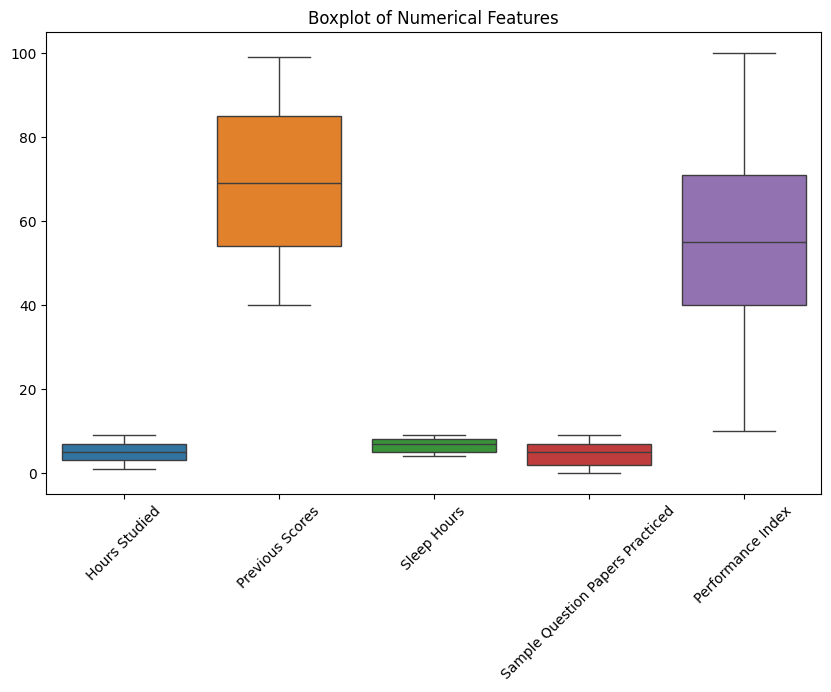

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df[numeric_columns])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

**Question 3: Drop Unimportant Columns**

**Unimportant columns are removed to keep only the features that are useful for analysis.**

In [26]:
print(df.columns.tolist())

['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


In [27]:
df_clean = df.drop(columns=['Extracurricular Activities'])

df_clean.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,9,1,91.0
1,4,82,4,2,65.0
2,8,51,7,2,45.0
3,5,52,5,2,36.0
4,7,75,8,5,66.0


In [28]:
print("Remaining Columns:")
print(df_clean.columns.tolist())

Remaining Columns:
['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index']


**Question 4: Correlation Between Target and Features**

**Correlation is calculated to understand the relationship between the target variable and the input features.**

**The target variable is Performance Index.**

In [29]:
correlation = df_clean.corr()

print(correlation)

                                  Hours Studied  Previous Scores  Sleep Hours  \
Hours Studied                          1.000000        -0.012390     0.001245   
Previous Scores                       -0.012390         1.000000     0.005944   
Sleep Hours                            0.001245         0.005944     1.000000   
Sample Question Papers Practiced       0.017463         0.007888     0.003990   
Performance Index                      0.373730         0.915189     0.048106   

                                  Sample Question Papers Practiced  \
Hours Studied                                             0.017463   
Previous Scores                                           0.007888   
Sleep Hours                                               0.003990   
Sample Question Papers Practiced                          1.000000   
Performance Index                                         0.043268   

                                  Performance Index  
Hours Studied                         

In [30]:
target_correlation = correlation['Performance Index'].sort_values(ascending=False)

print("Correlation with Performance Index:")
print(target_correlation)

Correlation with Performance Index:
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64


**Correlation Heatmap**

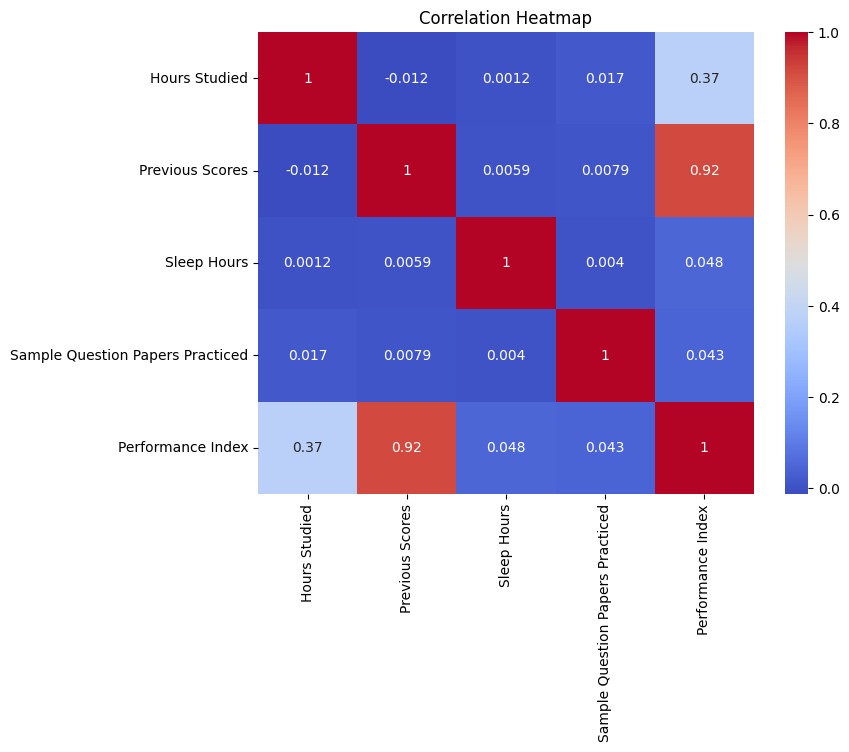

In [31]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**Conclusion**

In this practice, Exploratory Data Analysis was performed on the Student Performance dataset. The dataset shape, columns, and null values were checked. Outliers were detected using the IQR method. Unimportant columns were removed, and correlation between the target variable and features was calculated. These steps help in understanding and preparing the dataset for further analysis and machine learning.